# Multi-Objective Trade-Off Analysis for Pre-Filtered Pareto Front

This notebook provides comprehensive analysis of trade-off relationships between optimization objectives in railroad construction scheduling, focusing on the pre-filtered Pareto front to understand decision-making implications and objective conflicts.

## Analysis Framework:

### 1. **Interactive Trade-Off Exploration**
- **Dynamic Visualization**: Interactive widgets for exploring pairwise objective relationships
- **Real-Time Analysis**: Immediate feedback on trade-off magnitudes and directions
- **Quantitative Metrics**: Numerical trade-off coefficients for decision support

### 2. **Scientific Publication Quality Analysis**
- **LaTeX Rendering**: Professional mathematical notation and typography
- **Statistical Trade-Off Metrics**: Precise quantification of objective relationships
- **Export Capabilities**: PDF generation for academic and industrial reports

### 3. **Correlation Analysis**
- **Objective Interdependencies**: Correlation matrix visualization for understanding objective relationships
- **Conflict Identification**: Detection of competing objectives requiring trade-off decisions
- **Synergy Detection**: Identification of objectives that improve together

### 4. **Multi-Objective Optimization Context**
- **7 Optimization Objectives**: Comprehensive coverage of construction scheduling criteria
- **Pareto Front Analysis**: Focus on non-dominated solutions for practical decision-making
- **Trade-Off Quantification**: Mathematical characterization of objective conflicts

## Optimization Objectives Analyzed:

1. **Driver Violation**: Constraint satisfaction and regulatory compliance
2. **Commute Distance**: Worker transportation costs and efficiency
3. **Transport Machines**: Machine logistics and repositioning costs
4. **Transport Attachments**: Equipment transportation and allocation
5. **Machines**: Total machine resource requirements
6. **Workers**: Human resource allocation and staffing levels
7. **Attachments**: Equipment and tool allocation efficiency

## Real-Life Application Context:
- **Instance**: July 1, 2024 railroad construction scenario
- **Pre-Filtered Data**: Analysis of Pareto-optimal solutions only
- **Decision Support**: Quantitative basis for selecting optimal solutions
- **Practical Insights**: Understanding trade-offs for real-world deployment

This analysis enables decision-makers to understand the quantitative relationships between optimization objectives, supporting informed selection of solutions based on organizational priorities and constraints.

In [ ]:
"""
Interactive Multi-Objective Trade-Off Analysis

This cell implements an interactive visualization system for exploring trade-off
relationships between optimization objectives in the pre-filtered Pareto front,
enabling dynamic analysis of objective conflicts and decision-making support.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# === Data Loading for Pre-Filtered Pareto Front ===
# Load Pareto-optimal solutions from the pre-filtered dataset
# This CSV contains only non-dominated solutions, ensuring focus on feasible trade-offs
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront.csv")

# === Multi-Objective Definition ===
# Define all optimization objectives for comprehensive trade-off analysis
# Each objective represents a different aspect of railroad construction scheduling
objectives = [
    "Driver Violation",      # Regulatory compliance and constraint satisfaction
    "Commute Distance",      # Worker transportation costs and travel efficiency
    "Transport Machines",    # Machine logistics and repositioning expenses
    "Transport Attachments", # Equipment transportation and allocation costs
    "Machines",             # Total machine resource requirements
    "Workers",              # Human resource allocation and staffing needs
    "Attachments"           # Equipment and tool allocation efficiency
]

# === Interactive Widget Configuration ===
# Create dropdown widgets for dynamic objective selection
# Enable real-time exploration of different objective pairings
x_widget = widgets.Dropdown(
    options=objectives, 
    value="Machines",           # Default X-axis objective
    description="X:"            # Widget label for horizontal axis
)

y_widget = widgets.Dropdown(
    options=objectives, 
    value="Commute Distance",   # Default Y-axis objective
    description="Y:"            # Widget label for vertical axis
)

# Create output container for dynamic plot updates
output = widgets.Output()

# === Dynamic Trade-Off Analysis Function ===
def update_plot(*args):
    """
    Generate real-time trade-off visualization and analysis.
    
    This function creates scatter plots showing the relationship between
    selected objectives and calculates quantitative trade-off metrics
    to support decision-making processes.
    """
    with output:
        # Clear previous output for clean updates
        clear_output(wait=True)
        
        # === Objective Selection and Data Preparation ===
        # Extract selected objectives from widget values
        x_col, y_col = x_widget.value, y_widget.value
        
        # Filter and sort data for trade-off analysis
        # Remove missing values and sort by X-axis for consistent analysis
        sub_df = df[[x_col, y_col]].dropna().sort_values(x_col)

        # === Trade-Off Coefficient Calculation ===
        # Extract objective values for mathematical analysis
        x, y = sub_df[x_col].values, sub_df[y_col].values
        
        # Calculate finite differences for trade-off slope estimation
        dx, dy = np.diff(x), np.diff(y)  # Changes in X and Y objectives
        
        # Compute trade-off coefficients (dy/dx) with division by zero protection
        # Trade-off represents change in Y objective per unit change in X objective
        tradeoff = np.divide(dy, dx, 
                           out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                           where=dx != 0)                       # Only divide where dx ≠ 0
        
        # Calculate average absolute trade-off magnitude
        # This metric quantifies the typical trade-off strength between objectives
        avg_tradeoff = np.mean(np.abs(tradeoff[np.isfinite(tradeoff)]))

        # === Visualization Generation ===
        # Create professional scatter plot for trade-off visualization
        plt.figure(figsize=(8, 5))  # Standard figure size for clear visualization
        
        # Plot Pareto-optimal solutions as scatter points
        plt.scatter(x, y, alpha=0.8)  # Semi-transparent points for overlap visibility
        
        # Configure plot formatting with dynamic labels
        plt.xlabel(x_col)                           # X-axis objective name
        plt.ylabel(y_col)                           # Y-axis objective name
        plt.title(f"{y_col} vs. {x_col}")          # Descriptive title
        plt.grid(True)                              # Grid for value reading
        plt.tight_layout()                          # Optimize layout spacing
        
        # Display the visualization
        plt.show()
        
        # === Trade-Off Metric Display ===
        # Provide quantitative trade-off information for decision support
        print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} Δ{y_col} / Δ{x_col}")

# === Widget Event Binding ===
# Register callback functions for real-time updates
# Trigger plot updates whenever user changes objective selection
x_widget.observe(update_plot, names="value")  # Update when X-axis selection changes
y_widget.observe(update_plot, names="value")  # Update when Y-axis selection changes

# === Interface Initialization ===
# Generate initial plot with default objective selection
update_plot()

# Display interactive interface with widget controls and output area
# Horizontal box layout for clean widget arrangement
display(widgets.HBox([x_widget, y_widget]), output)

# === Analysis Benefits ===
# This interactive system provides:
# 1. Real-time exploration of objective trade-offs
# 2. Quantitative trade-off coefficients for decision support
# 3. Visual understanding of Pareto front structure
# 4. Dynamic analysis capability for different objective combinations

Output()

🔁 Avg. Trade-off: -40.6179 → On average, each additional unit of 'Attachments' results in a decrease of 40.62 in 'Transport Attachments'


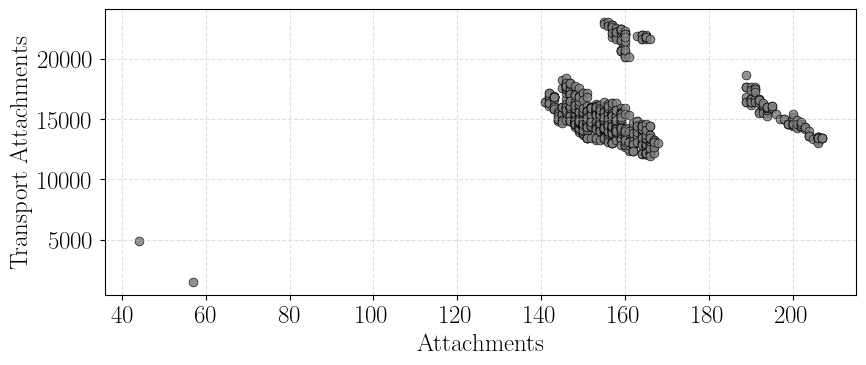

In [ ]:
"""
Scientific Publication Quality Trade-Off Analysis

This cell creates publication-ready trade-off visualizations with LaTeX rendering
and precise statistical analysis, suitable for academic papers and technical reports
focusing on multi-objective optimization trade-offs in railroad construction scheduling.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX Rendering Configuration for Scientific Publications ===
# Configure matplotlib for academic publication standards
# LaTeX rendering ensures mathematical notation and professional typography
rcParams.update({
    "text.usetex": True,        # Enable LaTeX text rendering for mathematical notation
    "font.family": "serif",     # Use serif fonts for academic publication style
    "font.size": 18,            # Base font size for readability in publications
    "axes.labelsize": 18,       # Axis label font size for clear identification
    "xtick.labelsize": 18,      # X-axis tick label size for precision reading
    "ytick.labelsize": 18,      # Y-axis tick label size for precision reading
})

# === Data Loading for Pre-Filtered Pareto Front Analysis ===
# Load Pareto-optimal solutions for scientific trade-off analysis
# Focus on pre-filtered data ensures analysis of only feasible, non-dominated solutions
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront.csv")

# === Objective Selection for Trade-Off Analysis ===
# Specify objective pair for detailed scientific analysis
# These can be modified to analyze different objective relationships
x_axis = "Attachments"                # X-axis objective: Equipment allocation count
y_axis = "Transport Attachments"      # Y-axis objective: Equipment transportation costs

# === Data Preprocessing for Statistical Analysis ===
# Filter and prepare data for rigorous trade-off calculation
# Remove missing values and sort by X-axis for consistent analysis
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values  # Extract X-axis objective values
y = sub_df[y_axis].values  # Extract Y-axis objective values

# === Scientific Visualization Setup ===
# Create publication-quality figure with optimal dimensions
plt.figure(figsize=(9, 4))  # Wide aspect ratio suitable for academic publications

# Plot Pareto-optimal solutions with professional styling
plt.scatter(x, y, 
           alpha=0.85,              # High opacity for clear point visibility
           s=40,                    # Point size optimized for publication clarity
           color="tab:grey",        # Neutral color for print compatibility
           edgecolors="black",      # Black edges for point definition
           linewidth=0.5)           # Thin edge lines for professional appearance

# === Professional Plot Formatting ===
# Configure axis labels and styling for scientific standards
plt.xlabel(x_axis)                      # X-axis label with objective name
plt.ylabel(y_axis)                      # Y-axis label with objective name
# Optional title (commented for clean publication appearance)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)

# Add professional grid for value reading precision
plt.grid(True, linestyle="--", alpha=0.4)  # Subtle dashed grid

# === Rigorous Trade-Off Statistical Analysis ===
# Perform precise trade-off calculation using unique data points only
# This approach eliminates bias from duplicate solutions

# Remove duplicate solutions to ensure accurate trade-off calculation
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)

# Extract unique objective values for statistical analysis
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

# === Trade-Off Coefficient Calculation ===
# Calculate finite differences for precise slope estimation
dx = np.diff(x_unique)  # Changes in X-axis objective
dy = np.diff(y_unique)  # Changes in Y-axis objective

# Compute trade-off coefficients with mathematical rigor
# Handle division by zero cases for robust calculation
tradeoff = np.divide(dy, dx, 
                    out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                    where=dx != 0)                       # Only divide where dx ≠ 0

# Calculate signed average trade-off for directional analysis
# Positive values indicate positive correlation, negative indicate trade-offs
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Interpretive Analysis ===
# Generate human-readable interpretation of trade-off direction and magnitude
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"     # Positive correlation
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}" # Negative correlation (trade-off)
    if avg_tradeoff_signed < 0
    else "no change"                                   # No correlation
)

# Display comprehensive trade-off analysis results
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → "
    f"On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)

# === Publication Output Preparation ===
# Finalize layout for publication standards
plt.tight_layout()

# Optional: Save as PDF for direct inclusion in academic papers
# Uncomment the following line to save publication-ready figure
#plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")

# Display the scientific visualization
plt.show()

# === Scientific Analysis Benefits ===
# This rigorous analysis provides:
# 1. Publication-quality visualizations with LaTeX rendering
# 2. Statistically precise trade-off coefficient calculation
# 3. Directional interpretation of objective relationships
# 4. Bias elimination through duplicate removal
# 5. Professional formatting suitable for peer-reviewed publications

<AxesSubplot:>

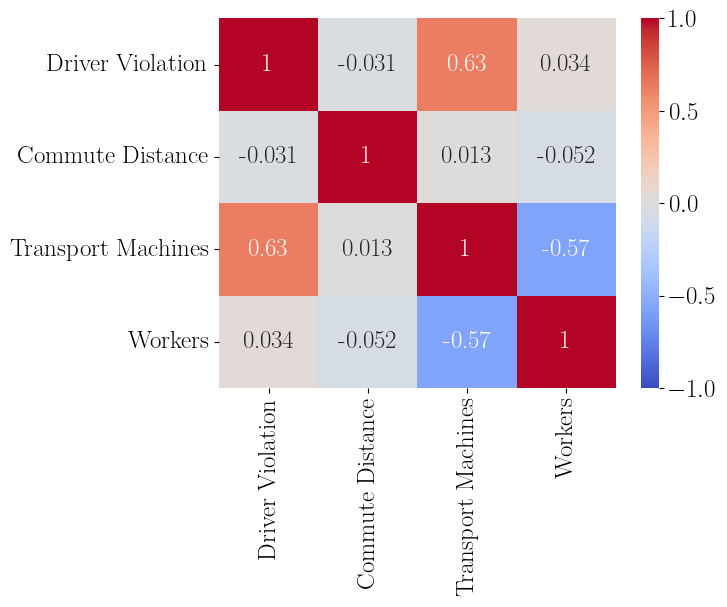

In [ ]:
"""
Comprehensive Correlation Analysis - Subset 1

This cell performs correlation analysis on a selected subset of optimization
objectives to identify relationships, conflicts, and synergies in the pre-filtered
Pareto front for railroad construction scheduling optimization.
"""

import seaborn as sns

# === Objective Subset Selection ===
# Focus analysis on specific objectives by excluding resource allocation metrics
# This subset emphasizes operational and logistical objectives over pure resource counts
objectives_corr = [
    obj for obj in objectives 
    if obj not in ["Attachments", "Transport Attachments", "Machines"]
]
# Resulting subset includes:
# - Driver Violation (regulatory compliance)
# - Commute Distance (worker transportation efficiency)
# - Transport Machines (machine logistics)
# - Workers (human resource requirements)

# === Correlation Matrix Visualization ===
# Generate professional correlation heatmap for subset analysis
# Correlation values range from -1 (perfect negative correlation) to +1 (perfect positive correlation)
sns.heatmap(
    df[objectives_corr].corr(),  # Compute Pearson correlation matrix
    annot=True,                  # Display correlation coefficients in cells
    cmap="coolwarm",            # Color map: blue (negative) to red (positive) correlation
    vmax=1,                     # Maximum value for color scaling
    vmin=-1                     # Minimum value for color scaling
)

# === Correlation Interpretation Guide ===
# Correlation coefficient interpretation:
# |r| ≥ 0.8: Strong correlation (objectives strongly related)
# 0.5 ≤ |r| < 0.8: Moderate correlation (noticeable relationship)
# 0.3 ≤ |r| < 0.5: Weak correlation (slight relationship)
# |r| < 0.3: Very weak/no correlation (objectives largely independent)
#
# Positive correlations: Objectives improve/worsen together
# Negative correlations: Trade-off relationships (conflicting objectives)

<AxesSubplot:>

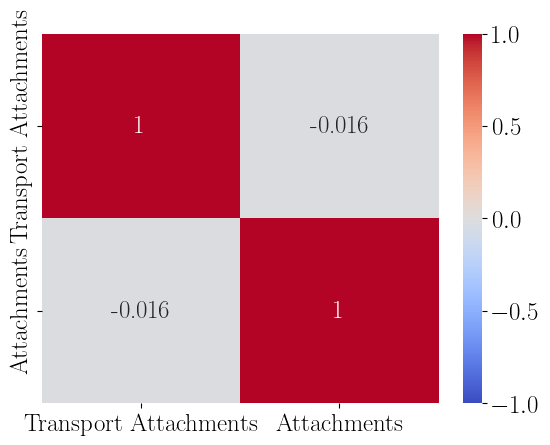

In [ ]:
"""
Focused Correlation Analysis - Equipment and Transportation Subset

This cell performs detailed correlation analysis on equipment and transportation
objectives, focusing specifically on attachment-related metrics to understand
resource allocation trade-offs in railroad construction scheduling.
"""

import seaborn as sns

# === Specialized Objective Subset Selection ===
# Focus analysis on equipment and transportation objectives only
# Exclude human resource and operational constraint objectives for specialized analysis
objectives_corr = [
    obj for obj in objectives 
    if obj not in ["Workers", "Transport Machines", "Machines", "Driver Violation", "Commute Distance"]
]
# Resulting focused subset includes:
# - Transport Attachments (equipment transportation costs)
# - Attachments (equipment allocation count)

# This subset specifically examines the relationship between:
# 1. Equipment allocation decisions (number of attachments)
# 2. Transportation costs for equipment (transport attachments)

# === Specialized Correlation Matrix Visualization ===
# Generate focused correlation heatmap for equipment-specific analysis
sns.heatmap(
    df[objectives_corr].corr(),  # Compute correlation matrix for equipment objectives
    annot=True,                  # Display correlation coefficients for precise analysis
    cmap="coolwarm",            # Standard correlation color scheme
    vmin=-1,                    # Full correlation range for maximum sensitivity
    vmax=1                      # Complete color scale utilization
)

# === Equipment Trade-Off Analysis Context ===
# This focused analysis reveals:
# 1. Direct relationship between equipment count and transportation costs
# 2. Trade-off intensity in equipment allocation decisions
# 3. Cost implications of equipment distribution strategies
# 4. Resource optimization patterns in attachment management
#
# Expected relationships:
# - Positive correlation: More attachments → Higher transport costs
# - Strong correlation indicates linear cost scaling
# - Weak correlation suggests optimization efficiency in equipment distribution